# 04 - Resultados: Embeddings (SVM + MiniLM)

In [1]:
import sys
from pathlib import Path
import joblib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# permitir import local se precisar
root_dir = Path.cwd().parent  # notebooks/ → raiz
sys.path.append(str(root_dir))

from src.models.utils_embeddings import load_split
from sentence_transformers import SentenceTransformer
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score
)

sns.set(style="whitegrid")
TEST_PATH = Path("../data/processed/test.csv")
ENCODER_PKL = Path("../models/sentence_transformer_encoder.pkl")
MODEL_PKL = Path("../models/linear_svm_embeddings.pkl")
RESULTS_CSV = Path("../models/results_embeddings.csv")

In [2]:
# Dados de teste
test_df = load_split(str(TEST_PATH))
X_text = test_df["text"].astype(str).tolist()
y_test = test_df["label"]
print(f"Test size: {len(y_test)} | classes: {y_test.value_counts().to_dict()}")

# Encoder
if ENCODER_PKL.exists():
    encoder = joblib.load(ENCODER_PKL)
    print("Encoder carregado via pickle:", ENCODER_PKL.name)
else:
    encoder = SentenceTransformer("all-MiniLM-L6-v2")
    print("ℹ️ Encoder carregado por nome: all-MiniLM-L6-v2")

# Embeddings
X_test = encoder.encode(X_text, show_progress_bar=True)
X_test.shape


Test size: 1080 | classes: {1: 540, 0: 540}
Encoder carregado via pickle: sentence_transformer_encoder.pkl


Batches:   0%|          | 0/34 [00:00<?, ?it/s]

(1080, 384)

In [3]:
# Modelo
model = joblib.load(MODEL_PKL)
print("Modelo:", MODEL_PKL.name)

# Predições e métricas
preds = model.predict(X_test)
acc = accuracy_score(y_test, preds)
f1  = f1_score(y_test, preds)

try:
    # Para comparar com TF-IDF usamos AUC de rótulos (se desejar scores, use decision_function)
    auc = roc_auc_score(y_test, preds)
except Exception:
    auc = None

print("=== Relatório (TEST) ===")
print(classification_report(y_test, preds, digits=4))
print(f"Acurácia: {acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}" if auc is not None else f"Acurácia: {acc:.4f} | F1: {f1:.4f}")


Modelo: linear_svm_embeddings.pkl
=== Relatório (TEST) ===
              precision    recall  f1-score   support

           0     0.7944    0.8444    0.8187       540
           1     0.8340    0.7815    0.8069       540

    accuracy                         0.8130      1080
   macro avg     0.8142    0.8130    0.8128      1080
weighted avg     0.8142    0.8130    0.8128      1080

Acurácia: 0.8130 | F1: 0.8069 | AUC: 0.8130


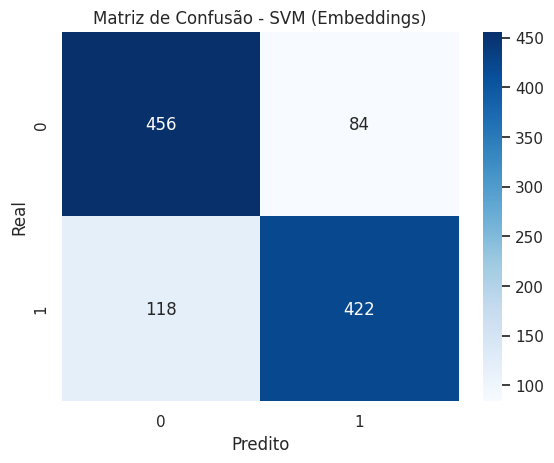

In [4]:
cm = confusion_matrix(y_test, preds)
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
ax.set_title("Matriz de Confusão - SVM (Embeddings)")
ax.set_xlabel("Predito")
ax.set_ylabel("Real")
plt.show()

In [5]:
df_emb = pd.DataFrame([{
    "Modelo": "SVM (Embeddings)",
    "Acurácia": round(acc, 4),
    "F1-Score": round(f1, 4),
    "AUC": round(auc, 4) if auc is not None else None
}])
display(df_emb)

# sobrescreve/garante o CSV usado pelo notebook 05
df_emb.to_csv(RESULTS_CSV, index=False)
print(f"Resultados consolidados salvos em: {RESULTS_CSV}")

,Modelo,Acurácia,F1-Score,AUC
0,SVM (Embeddings),0.813,0.8069,0.813


Resultados consolidados salvos em: ../models/results_embeddings.csv


### Conclusões

- O modelo **TF-IDF + Random Forest** apresentou o melhor desempenho geral (F1 ≈ 0.96), 
  enquanto os modelos com embeddings **all-MiniLM-L6-v2** atingiram cerca de F1 ≈ 0.81.
- Essa diferença é esperada: o *Fake.br Corpus* é pequeno (~7 mil textos) e fortemente lexical,
  o que favorece métodos baseados em frequência de termos.
- Os **Sentence Transformers** capturam contexto semântico, mas requerem fine-tuning ou
  grandes volumes de dados para superarem abordagens clássicas.
- Assim, o TF-IDF permanece o **baseline mais eficaz** e interpretável neste domínio,
  enquanto os embeddings demonstram o potencial das representações semânticas
  em aplicações futuras com bases maiores.